In [1]:
import sys
sys.path.insert(1, '/home/bricej/MyPythonLibrary/StageM2_IVT/library/')
import domain
from domain import *
from climbas import *
import numpy as np
import xarray as xr
import pandas as pd
from netCDF4 import Dataset
from scipy import stats
import scipy.stats as stats
import matplotlib.pyplot as plt

# Period

In [2]:
iyear = 1960
fyear = 2025
variables = ['tcwv', 'vimd']
domains = ['HMA','HK','SL','TP','CH','SEH']

# tcwv & VIMD Data

In [3]:
var_dict = {}

files = {'tcwv': 'tcwv_monthly_era5_1940-2025_NH_025x025.nc',
         'vimd': 'vimd_monthly_era5_1940-2025_NH_025x025.nc'}

path = '/bettik/PROJECTS/pr-regional-climate/bricej/era5/monthly/'

for var in variables:
    var_dict[var] = {}
    var_data = xr.open_dataset(path + files[var])[var]

    var_data = var_data.rename({'valid_time': 'time'})
    var_data = var_data.rename({'longitude': 'lon'})
    var_data = var_data.rename({'latitude': 'lat'})

    # pour alléger le dossier 
    var_data = var_data.drop_vars(['number','expver'], errors='ignore')  # les variables inutiles
    var_data.attrs = {}  # les atributs pas utiles pour les calculs
    
    var_data = var_data.sel(time=slice(str(iyear),str(fyear)))
    
    for domain in domains:
            var_dict[var][domain] = field_dom(var_data,domain)

# MONTHLY MEAN DATASETS DOMAINS

In [4]:
var_mean_dict = {}

for var in variables:
    var_mean_dict[var]={}
    print(var)
    for domain in domains:
        var_mean_dict[var][domain] = var_dict[var][domain].groupby('time.month').mean('time', skipna=True)
        var_mean_dict[var][domain] = var_mean_dict[var][domain].mean(dim=['lat','lon'], skipna=True)
        print(domain)


tcwv
HMA
HK
SL
TP
CH
SEH
vimd
HMA
HK
SL
TP
CH
SEH


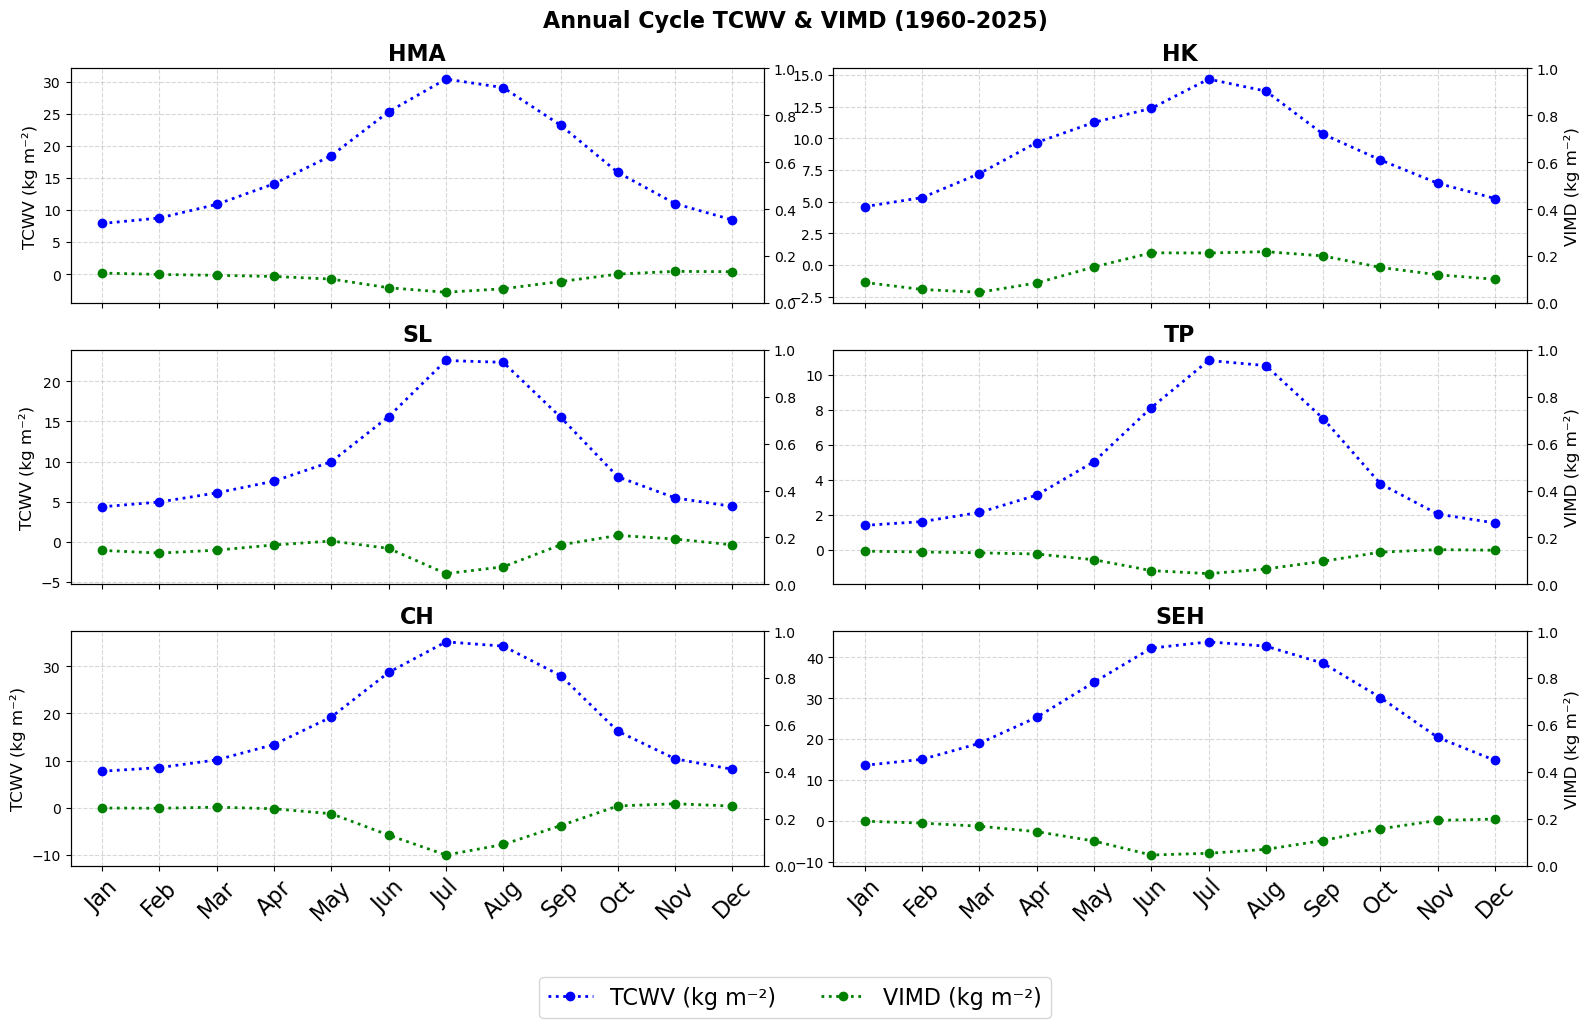

In [5]:
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
unite = {'tcwv': 'kg m⁻²',
        'vimd': 'kg m⁻²'}

colors = {'tcwv': 'blue',
        'vimd': 'green'}

fig, axes = plt.subplots(3, 2, figsize=(16,10))
axes = axes.flatten()

handles_all = []
labels_all = []

for i, dom in enumerate(domains):

    ax = axes[i]
    ax2 = ax.twinx()

    # --- TCWV
    da_tcwv = var_mean_dict['tcwv'][dom]
    l1, = ax.plot(
        da_tcwv['month'], da_tcwv.values,
        marker='o', linestyle=':', color=colors['tcwv'],
        label=f'TCWV ({unite["tcwv"]})', linewidth=2
    )

    # --- vimd
    da_tcwv = var_mean_dict['vimd'][dom]
    l2, = ax.plot(
        da_tcwv['month'], da_tcwv.values,
        marker='o', linestyle=':', color=colors['vimd'],
        label=f'VIMD ({unite["vimd"]})', linewidth=2
    )

    # récupérer légende sur la première figure
    if i == 0:
        handles_all.extend([l1, l2])
        labels_all.extend([l1.get_label(), l2.get_label()])

    # --- reste inchangé
    ax.set_title(dom, fontsize=16, weight="bold")
    ax.set_xticks(range(1,13))

    if i in [4, 5]:
        ax.set_xticklabels(months, rotation=45, fontsize=16)
    else:
        ax.tick_params(labelbottom=False)

    if i in [0, 2, 4]:
        ax.set_ylabel('TCWV (kg m⁻²)', fontsize=12)
    if i in [1, 3, 5]:
        ax2.set_ylabel('VIMD (kg m⁻²)', fontsize=12)

    ax.grid(True, linestyle='--', alpha=0.5)

# --- légende
fig.legend(
    handles_all,
    labels_all,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.04),
    ncol=2,
    fontsize=16,
    frameon=True
)

fig.suptitle(f'Annual Cycle TCWV & VIMD ({iyear}-{fyear})', fontsize=16, weight='bold')

plt.tight_layout(rect=[0,0.05,1,1])
plt.subplots_adjust(hspace=0.2, wspace=0.1)
plt.show()

# Comparing with ERA5 and CHIRPS precipitation

In [6]:
iyear = 1960
fyear = 2025
models = ['CHIRPS','ERA5']
domains = ['HMA','HK','SL','TP','CH','SEH']

In [7]:
tp_datasets = {}

files = {'CHIRPS': 'tp_HMA_1981-2025_CHIRPS.nc',
        'ERA5': 'tp_HMA_1940-2025_ERA5.nc'}

path = '/bettik/PROJECTS/pr-regional-climate/bricej/tp_datasets/'


for model in models:
    tp_datasets[model] = {}
    tp_model = xr.open_dataset(path + files[model])['tp']
    if model=='ERA5':
        tp_model=tp_model.sel(time=slice(str(iyear),str(fyear)))
    else:
            tp_model=tp_model.sel(time=slice(str(1981),str(2024)))
    for domain in domains:
        tp_datasets[model][domain] = field_dom(tp_model,domain)

In [8]:
tp_mean_dict = {}

for model in models:
    tp_mean_dict[model]={}
    print(model)
    for domain in domains:
        tp_mean_dict[model][domain] = tp_datasets[model][domain].groupby('time.month').mean('time', skipna=True)
        tp_mean_dict[model][domain] = tp_mean_dict[model][domain].mean(dim=['lat','lon'], skipna=True)
        print(domain)

CHIRPS
HMA
HK
SL
TP
CH
SEH
ERA5
HMA
HK
SL
TP
CH
SEH


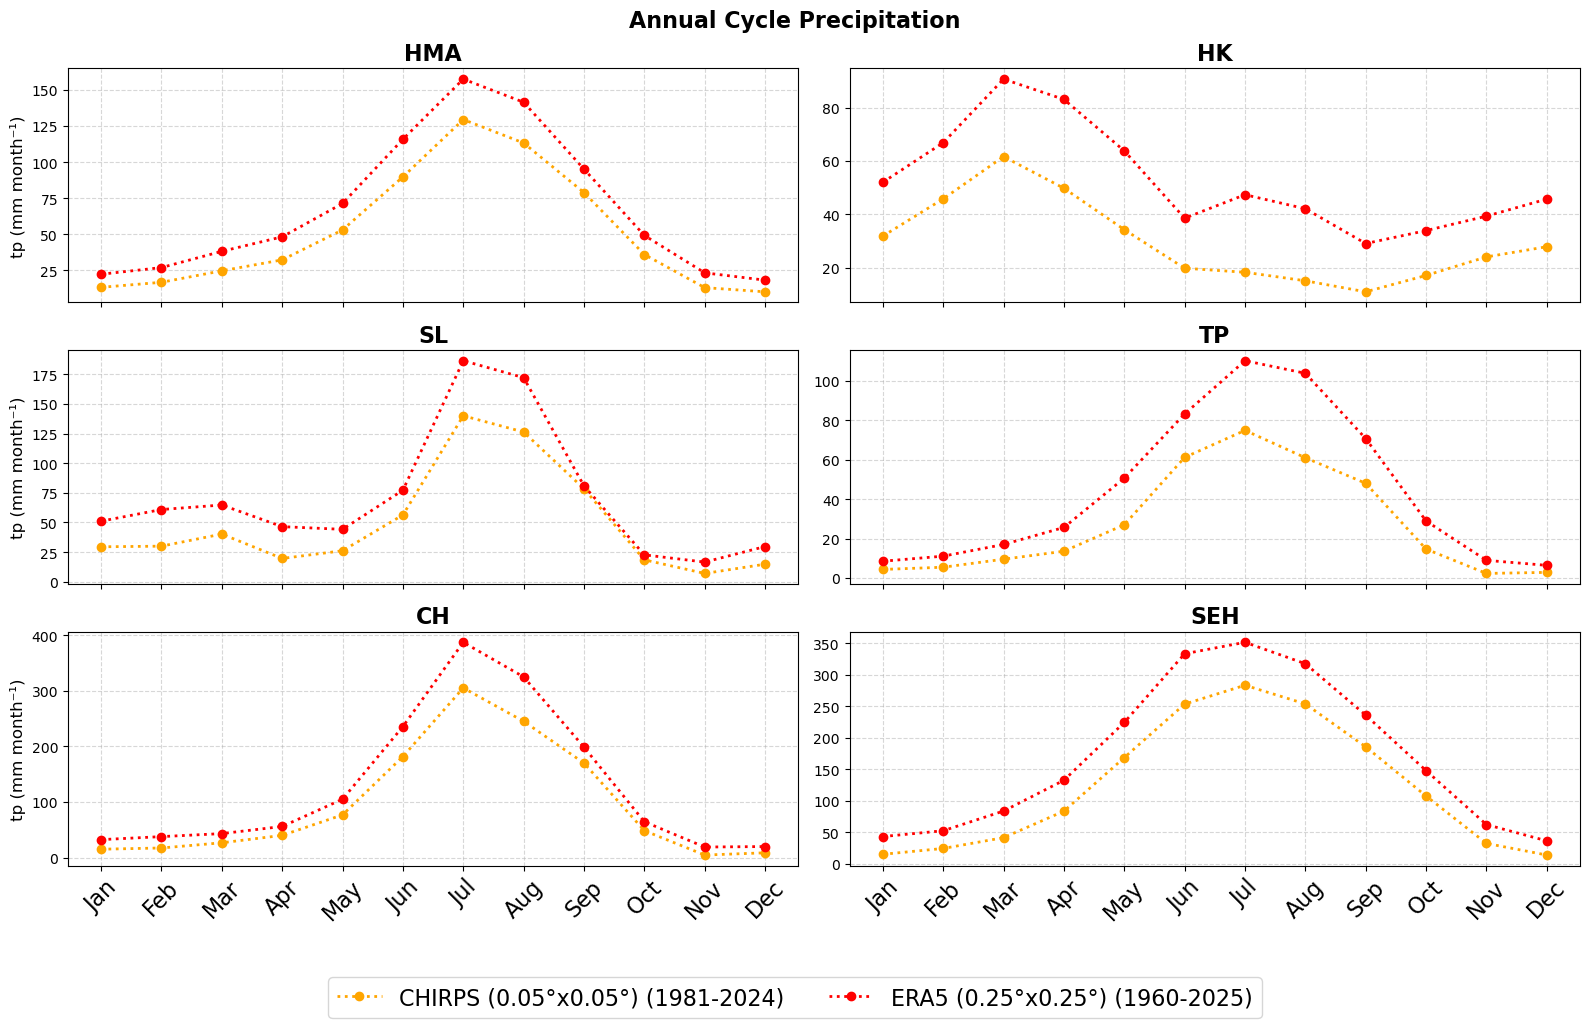

In [9]:
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
resolutions = {'CHIRPS': '0.05°x0.05°',
               'ERA5': '0.25°x0.25°'}
period = {'CHIRPS': '1981-2024',
               'ERA5': '1960-2025'}
colors = {'CHIRPS': 'orange',
          'ERA5': 'red'}

fig, axes = plt.subplots(3, 2, figsize=(16,10))
axes = axes.flatten()

for i, dom in enumerate(domains):

    ax = axes[i]

    for model in models:
        da = tp_mean_dict[model][dom]
        ax.plot(da['month'], da.values, marker='o', linestyle=':', color=colors[model], label=f'{model} ({resolutions[model]}) ({period[model]})', linewidth=2)

    ax.set_title(dom, fontsize=16, weight="bold")
    ax.set_xticks(range(1,13))
    
    if i in [0, 2, 4]:  # colonne gauche
        ax.set_ylabel('tp (mm month⁻¹)', fontsize=12)
    if i in [4, 5]:  # ligne du bas
        ax.set_xticklabels(months, rotation=45, fontsize=16)
    if i in [0,1,2,3]:
        ax.tick_params(labelbottom=False)
    
    ax.grid(True, linestyle='--', alpha=0.5)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.04),
    ncol=3,
    fontsize=16,
    frameon=True
)
fig.suptitle(f'Annual Cycle Precipitation', fontsize=16, weight='bold')

plt.tight_layout(rect=[0,0.05,1,1])
plt.show()

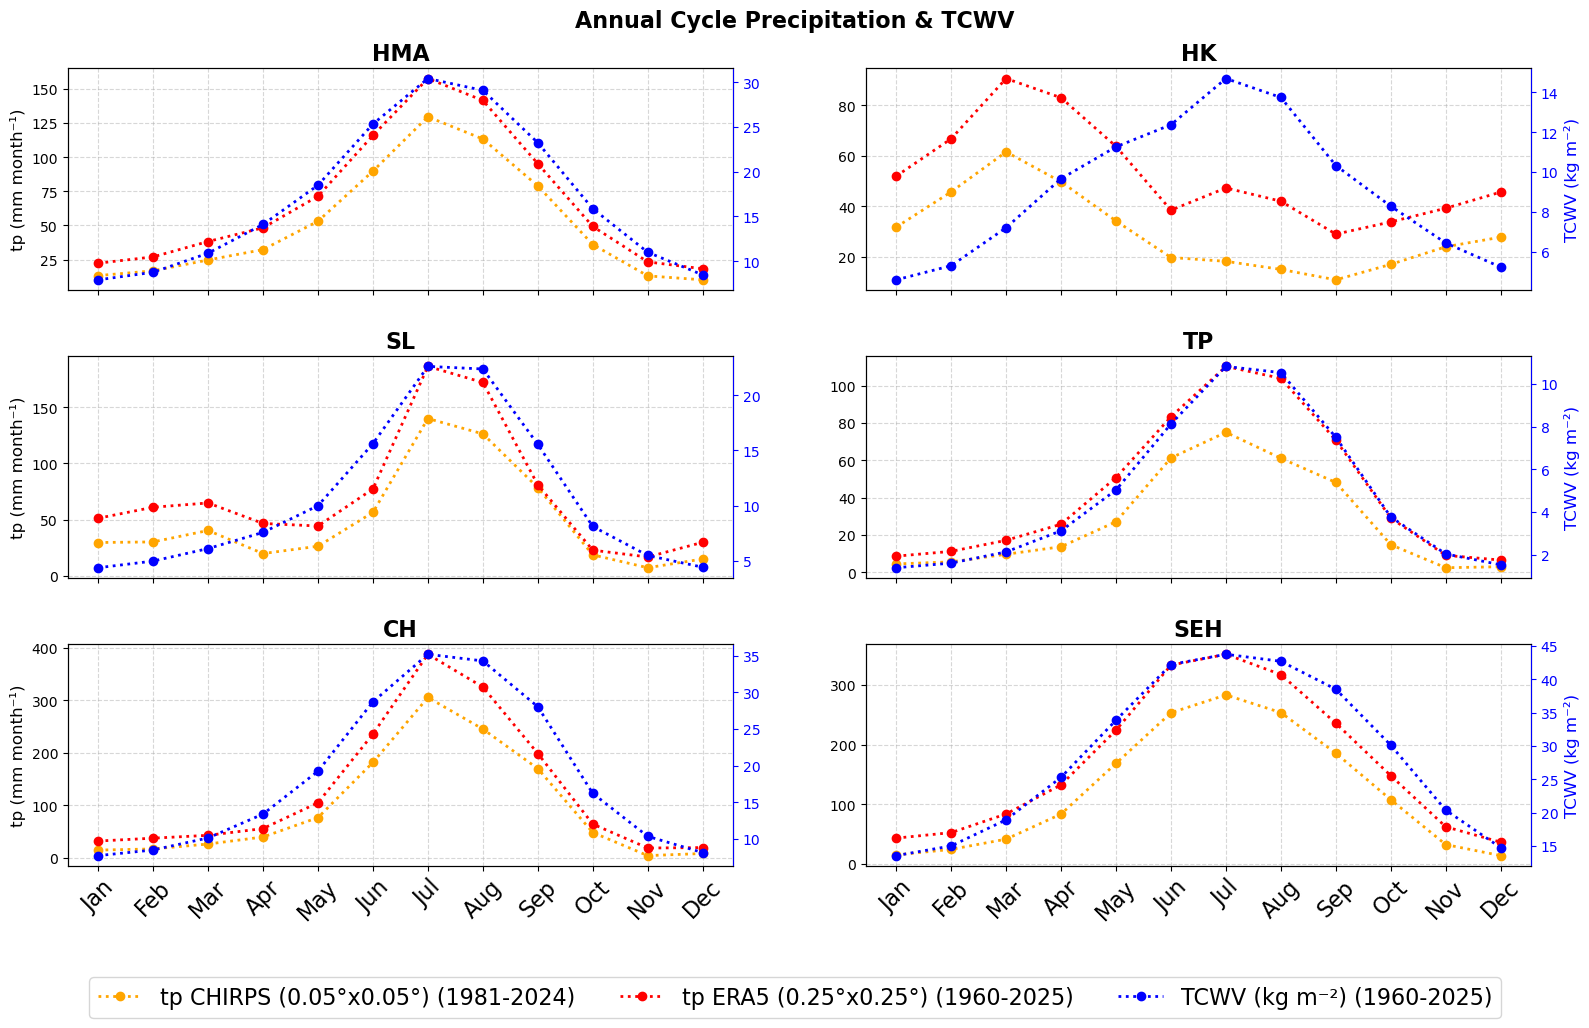

In [10]:
fig, axes = plt.subplots(3, 2, figsize=(16,10))
axes = axes.flatten()

handles_all = []
labels_all = []

for i, dom in enumerate(domains):

    ax = axes[i]
    ax2 = ax.twinx()  # axe droit
    # mettre l'axe droit en bleu
    ax2.tick_params(axis='y', colors='blue')
    ax2.yaxis.label.set_color('blue')
    ax2.spines['right'].set_color('blue')

    # --- PRECIP (axe gauche)
    for model in models:
        da = tp_mean_dict[model][dom]
        l, = ax.plot(
            da['month'], da.values,
            marker='o', linestyle=':',
            color=colors[model],
            label=f'tp {model} ({resolutions[model]}) ({period[model]})',
            linewidth=2
        )

        # stocker une seule fois
        if i == 0:
            handles_all.append(l)
            labels_all.append(l.get_label())

    # --- TCWV (axe droit)
    da_tcwv = var_mean_dict['tcwv'][dom]
    l_tcwv, = ax2.plot(
        da_tcwv['month'], da_tcwv.values,
        marker='o', linestyle=':',
        color='blue',
        label=f'TCWV (kg m⁻²) ({period[model]})',
        linewidth=2
    )

    if i == 0:
        handles_all.append(l_tcwv)
        labels_all.append(l_tcwv.get_label())

    # --- TITRES
    ax.set_title(dom, fontsize=16, weight="bold")
    ax.set_xticks(range(1,13))

    # --- X ticks
    if i in [4, 5]:
        ax.set_xticklabels(months, rotation=45, fontsize=16)
    else:
        ax.tick_params(labelbottom=False)

    # --- Y labels
    if i in [0, 2, 4]:
        ax.set_ylabel('tp (mm month⁻¹)', fontsize=12)
    if i in [1, 3, 5]:
        ax2.set_ylabel('TCWV (kg m⁻²)', fontsize=12)

    ax.grid(True, linestyle='--', alpha=0.5)

# --- LEGENDE
fig.legend(
    handles_all,
    labels_all,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.04),
    ncol=3,
    fontsize=16,
    frameon=True
)

fig.suptitle('Annual Cycle Precipitation & TCWV', fontsize=16, weight='bold')

plt.tight_layout(rect=[0,0.05,1,1])
plt.subplots_adjust(hspace=0.3, wspace=0.2)

plt.show()

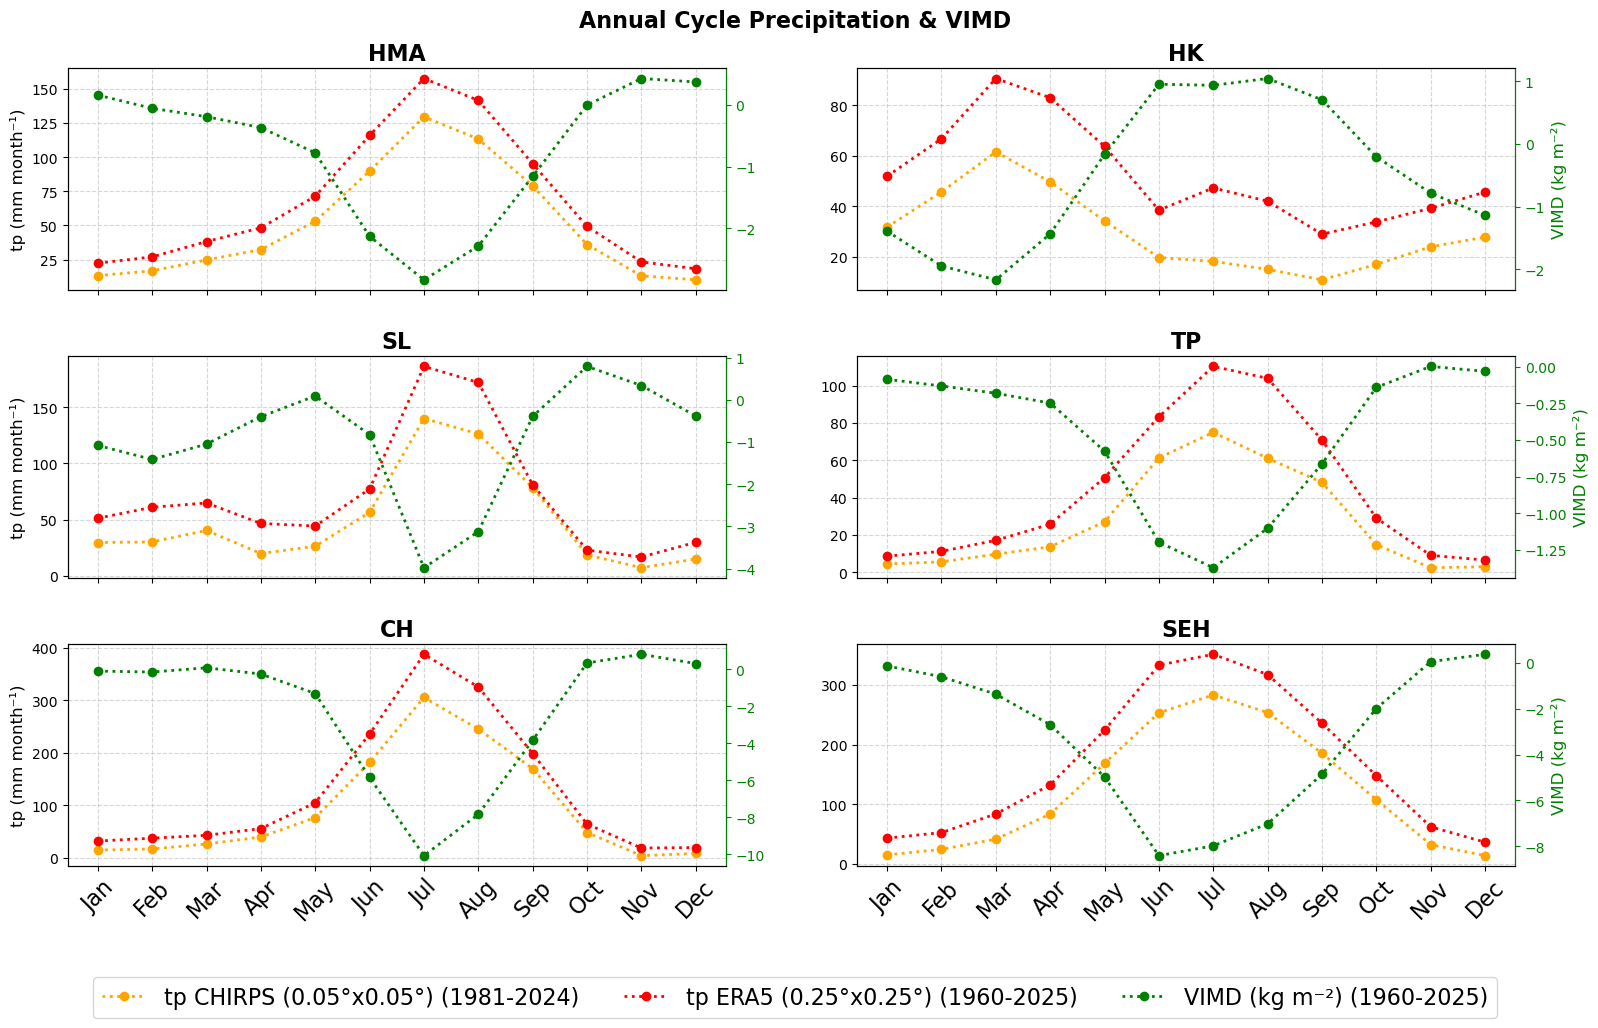

In [12]:
fig, axes = plt.subplots(3, 2, figsize=(16,10))
axes = axes.flatten()

handles_all = []
labels_all = []

for i, dom in enumerate(domains):

    ax = axes[i]
    ax2 = ax.twinx()  # axe droit
    # mettre l'axe droit en lightseagreen
    ax2.tick_params(axis='y', colors='green')
    ax2.yaxis.label.set_color('green')
    ax2.spines['right'].set_color('green')

    # --- PRECIP (axe gauche)
    for model in models:
        da = tp_mean_dict[model][dom]
        l, = ax.plot(
            da['month'], da.values,
            marker='o', linestyle=':',
            color=colors[model],
            label=f'tp {model} ({resolutions[model]}) ({period[model]})',
            linewidth=2
        )

        # stocker une seule fois
        if i == 0:
            handles_all.append(l)
            labels_all.append(l.get_label())

    # --- VIMD (axe droit)
    da_tcwv = var_mean_dict['vimd'][dom]
    l_tcwv, = ax2.plot(
        da_tcwv['month'], da_tcwv.values,
        marker='o', linestyle=':',
        color='green',
        label=f'VIMD (kg m⁻²) ({period[model]})',
        linewidth=2
    )

    if i == 0:
        handles_all.append(l_tcwv)
        labels_all.append(l_tcwv.get_label())

    # --- TITRES
    ax.set_title(dom, fontsize=16, weight="bold")
    ax.set_xticks(range(1,13))

    # --- X ticks
    if i in [4, 5]:
        ax.set_xticklabels(months, rotation=45, fontsize=16)
    else:
        ax.tick_params(labelbottom=False)

    # --- Y labels
    if i in [0, 2, 4]:
        ax.set_ylabel('tp (mm month⁻¹)', fontsize=12)
    if i in [1, 3, 5]:
        ax2.set_ylabel('VIMD (kg m⁻²)', fontsize=12)

    ax.grid(True, linestyle='--', alpha=0.5)

# --- LEGENDE
fig.legend(
    handles_all,
    labels_all,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.04),
    ncol=3,
    fontsize=16,
    frameon=True
)

fig.suptitle('Annual Cycle Precipitation & VIMD', fontsize=16, weight='bold')

plt.tight_layout(rect=[0,0.05,1,1])
plt.subplots_adjust(hspace=0.3, wspace=0.2)

plt.show()

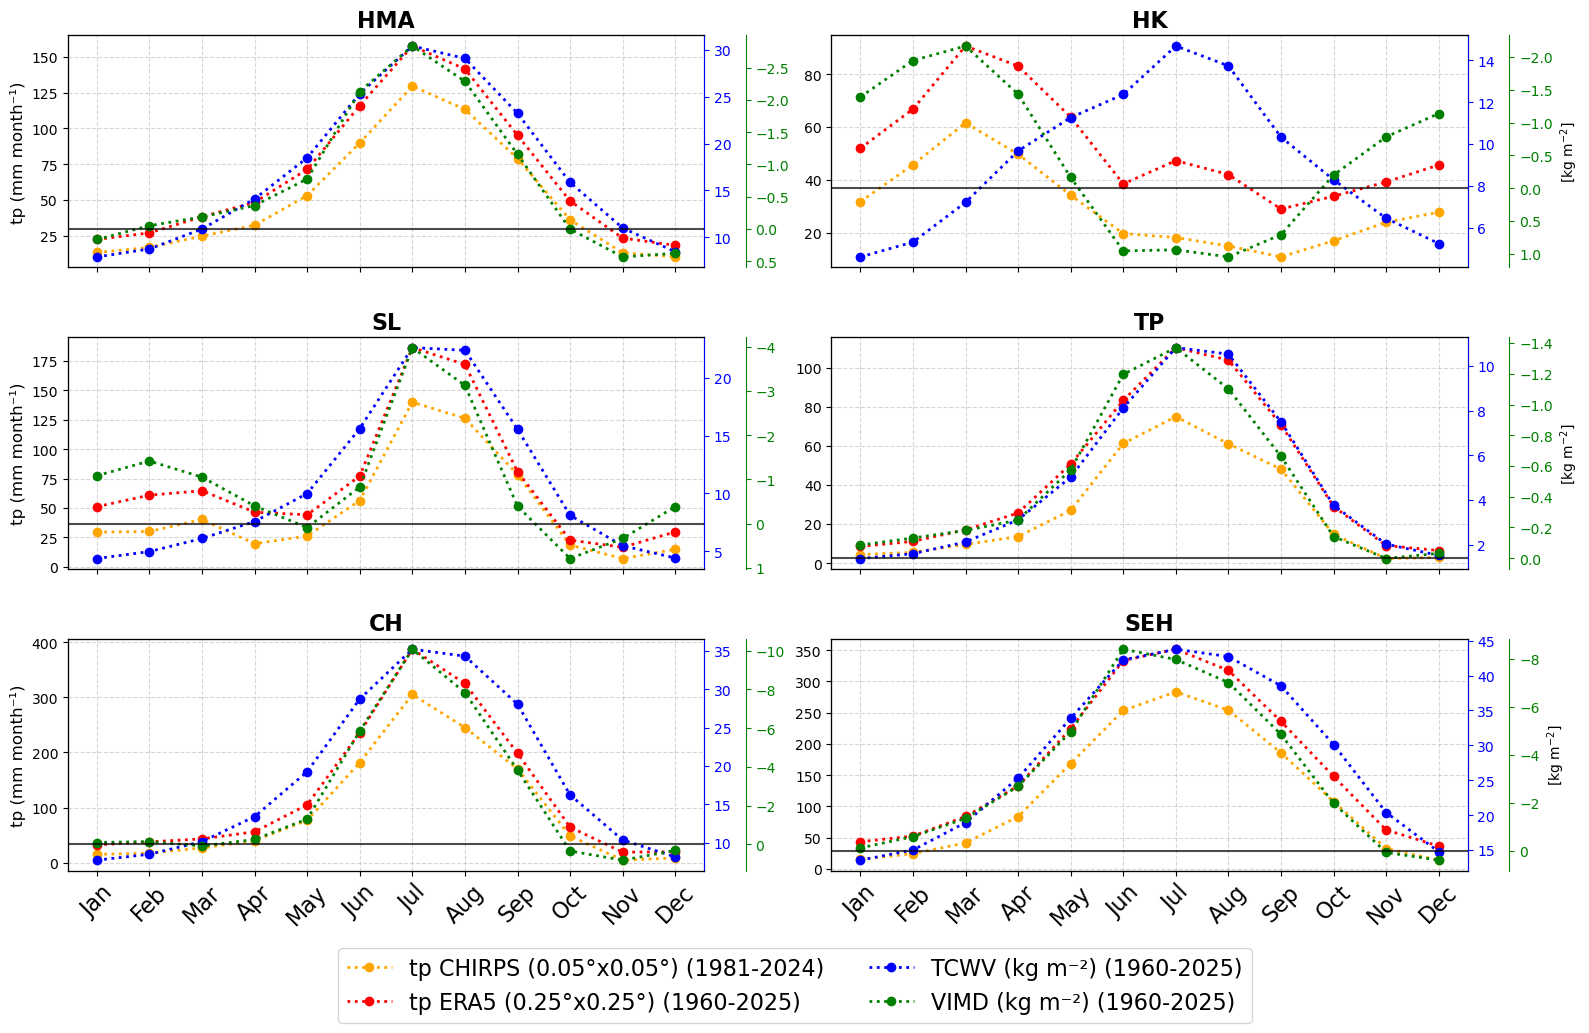

In [23]:
fig, axes = plt.subplots(3, 2, figsize=(16,10))
axes = axes.flatten()

handles_all = []
labels_all = []

for i, dom in enumerate(domains):

    ax = axes[i]
    
    ax2 = ax.twinx()  # axe droit 1
    # mettre l'axe droit en bleu
    ax2.tick_params(axis='y', colors='blue')
    ax2.yaxis.label.set_color('blue')
    ax2.spines['right'].set_color('blue')

    ax3 = ax.twinx()  # axe droit 2
    ax3.invert_yaxis() # inverser l'axe
    ax3.spines['right'].set_position(('outward', 30))  # décale de 60 points
    # mettre l'axe droit en vert
    ax3.tick_params(axis='y', colors='green')
    ax3.yaxis.label.set_color('green')
    ax3.spines['right'].set_color('green')

    # --- PRECIP (axe gauche)
    for model in models:
        da = tp_mean_dict[model][dom]
        l, = ax.plot(
            da['month'], da.values,
            marker='o', linestyle=':',
            color=colors[model],
            label=f'tp {model} ({resolutions[model]}) ({period[model]})',
            linewidth=2
        )

        # stocker une seule fois
        if i == 0:
            handles_all.append(l)
            labels_all.append(l.get_label())

    # --- TCWV (axe droit) 1
    da_tcwv = var_mean_dict['tcwv'][dom]
    l_tcwv, = ax2.plot(
        da_tcwv['month'], da_tcwv.values,
        marker='o', linestyle=':',
        color='blue',
        label=f'TCWV (kg m⁻²) ({period[model]})',
        linewidth=2
    )

    # --- VIMD (axe droit) 2
    da_vimd = var_mean_dict['vimd'][dom]
    l_tcwv2, = ax3.plot(
        da_vimd['month'], da_vimd.values,
        marker='o', linestyle=':',
        color='green',
        label=f'VIMD (kg m⁻²) ({period[model]})',
        linewidth=2
    )

    # ligne horizontale à 0 pour VIMD
    ax3.axhline(y=0,color='black',linestyle='-',linewidth=1.5,alpha=0.7)

    if i == 0:
        handles_all.append(l_tcwv)
        labels_all.append(l_tcwv.get_label())

        handles_all.append(l_tcwv2)
        labels_all.append(l_tcwv2.get_label())

    # --- TITRES
    ax.set_title(dom, fontsize=16, weight="bold")
    ax.set_xticks(range(1,13))

    # --- X ticks
    if i in [4, 5]:
        ax.set_xticklabels(months, rotation=45, fontsize=16)
    else:
        ax.tick_params(labelbottom=False)

    # --- Y labels
    if i in [0, 2, 4]:
        ax.set_ylabel('tp (mm month⁻¹)', fontsize=12)
    if i in [1, 3, 5]:
        ax3.set_ylabel(r'[kg m$^{-2}$]', color='black')

    ax.grid(True, linestyle='--', alpha=0.5)

# --- LEGENDE
fig.legend(
    handles_all,
    labels_all,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.04),
    ncol=2,
    fontsize=16,
    frameon=True
)

plt.tight_layout(rect=[0,0.05,1,1])
plt.subplots_adjust(hspace=0.3, wspace=0.2)

plt.show()